In [ ]:
City-level order summary
query: for each city, show total orders, total revenue, avg order value, sorted by total orders descending.

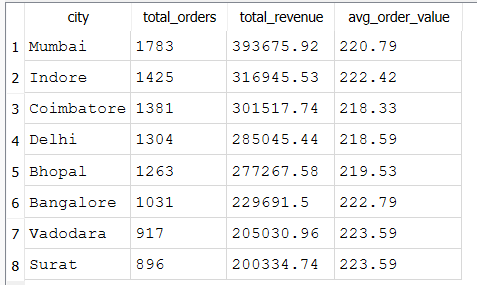

In [ ]:
 Cancellation rate per city
Write a query: for each city, show total orders, cancelled count, and cancellation rate as a percentage.

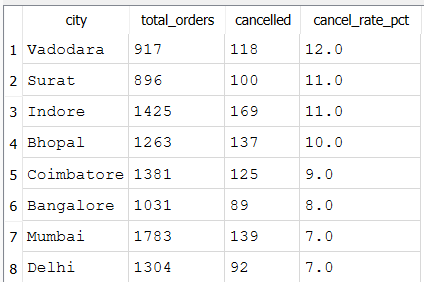

In [ ]:
SELECT
    DATE(order_time)              AS order_date,
    COUNT(*)                      AS daily_orders,
    ROUND(SUM(order_value), 2)    AS daily_revenue
FROM orders
WHERE DATE(order_time) >= DATE('2024-03-31', '-30 days')
GROUP BY DATE(order_time)
ORDER BY order_date;

2024-03-01	97	21972.97
2024-03-02	128	27467.56
2024-03-03	103	22010.67
2024-03-04	104	21306.5
2024-03-05	110	24228.34
2024-03-06	108	23135.94
2024-03-07	111	23130.28
2024-03-08	106	22427.06
2024-03-09	104	24668.15
2024-03-10	119	25977.6
2024-03-11	105	22711.01
2024-03-12	102	22892.49
2024-03-13	114	26003.36
2024-03-14	111	23194.4
2024-03-15	107	21947.7
2024-03-16	112	24868.25
2024-03-17	120	27499.8
2024-03-18	119	25230.7
2024-03-19	108	25112.0
2024-03-20	100	21115.74
2024-03-21	123	27669.56
2024-03-22	112	26577.11
2024-03-23	128	27442.75
2024-03-24	103	23475.59
2024-03-25	118	27369.96
2024-03-26	107	22688.91
2024-03-27	109	25623.14
2024-03-28	125	27773.48
2024-03-29	101	21796.81
2024-03-30	103	23949.53
2024-03-31	104	22423.58


In [ ]:
SELECT
    o.city,
    o.city_tier,
    ROUND(AVG(d.delivery_time_min), 1)    AS avg_delivery_min,
    COUNT(*)                               AS delivered_orders
FROM orders o
INNER JOIN delivery d ON o.order_id = d.order_id
WHERE o.status = 'delivered'
GROUP BY o.city, o.city_tier
ORDER BY avg_delivery_min DESC;

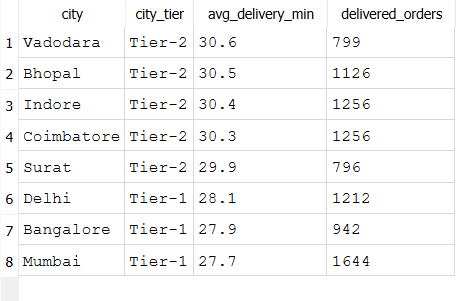

In [ ]:
SELECT
    o.city,
    o.city_tier,
    COUNT(*)                                           AS delivered,
    SUM(d.delay_flag)                                  AS delayed_count,
    ROUND(SUM(d.delay_flag) * 100.0 / COUNT(*), 2)    AS delay_rate_pct
FROM orders o
INNER JOIN delivery d ON o.order_id = d.order_id
WHERE o.status = 'delivered'
GROUP BY o.city, o.city_tier
ORDER BY delay_rate_pct DESC;

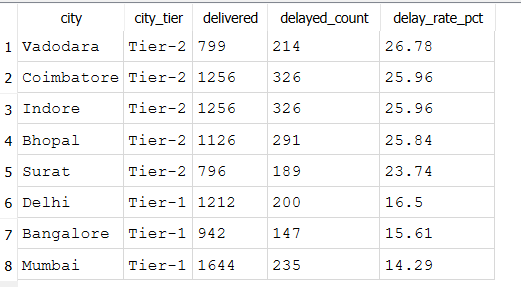

In [ ]:
WITH weekly AS (
    SELECT
        city,
        city_tier,
        strftime('%Y-%W', order_time)   AS year_week,
        COUNT(*)                         AS orders
    FROM orders
    GROUP BY city, city_tier, year_week
),
with_lag AS (
    SELECT
        city,
        city_tier,
        year_week,
        orders,
        LAG(orders, 1) OVER (
            PARTITION BY city
            ORDER BY year_week
        )                                AS prev_week_orders
    FROM weekly
)
SELECT
    city,
    city_tier,
    year_week,
    orders                                                  AS this_week,
    prev_week_orders                                        AS last_week,
    ROUND((orders - prev_week_orders) * 100.0
          / prev_week_orders, 1)                            AS pct_change
FROM with_lag
WHERE prev_week_orders IS NOT NULL
ORDER BY city, year_week;

Bangalore	Tier-1	2024-02	69	76	-9.2
Bangalore	Tier-1	2024-03	84	69	21.7
Bangalore	Tier-1	2024-04	48	84	-42.9
Bangalore	Tier-1	2024-05	81	48	68.8
Bangalore	Tier-1	2024-06	82	81	1.2
Bangalore	Tier-1	2024-07	79	82	-3.7
Bangalore	Tier-1	2024-08	102	79	29.1
Bangalore	Tier-1	2024-09	95	102	-6.9
Bangalore	Tier-1	2024-10	81	95	-14.7
Bangalore	Tier-1	2024-11	76	81	-6.2
Bangalore	Tier-1	2024-12	77	76	1.3
Bangalore	Tier-1	2024-13	81	77	5.2
Bhopal	Tier-2	2024-02	83	80	3.8
Bhopal	Tier-2	2024-03	97	83	16.9
Bhopal	Tier-2	2024-04	111	97	14.4
Bhopal	Tier-2	2024-05	97	111	-12.6
Bhopal	Tier-2	2024-06	89	97	-8.2
Bhopal	Tier-2	2024-07	104	89	16.9
Bhopal	Tier-2	2024-08	102	104	-1.9
Bhopal	Tier-2	2024-09	85	102	-16.7
Bhopal	Tier-2	2024-10	104	85	22.4
Bhopal	Tier-2	2024-11	97	104	-6.7
Bhopal	Tier-2	2024-12	109	97	12.4
Bhopal	Tier-2	2024-13	105	109	-3.7
Coimbatore	Tier-2	2024-02	97	91	6.6
Coimbatore	Tier-2	2024-03	108	97	11.3
Coimbatore	Tier-2	2024-04	103	108	-4.6
Coimbatore	Tier-2	2024-05	116	103	12.6
Coimbatore	Tier-2	2024-06	116	116	0.0
Coimbatore	Tier-2	2024-07	119	116	2.6
Coimbatore	Tier-2	2024-08	114	119	-4.2
Coimbatore	Tier-2	2024-09	114	114	0.0
Coimbatore	Tier-2	2024-10	87	114	-23.7
Coimbatore	Tier-2	2024-11	106	87	21.8
Coimbatore	Tier-2	2024-12	124	106	17.0
Coimbatore	Tier-2	2024-13	86	124	-30.6
Delhi	Tier-1	2024-02	105	89	18.0
Delhi	Tier-1	2024-03	112	105	6.7
Delhi	Tier-1	2024-04	100	112	-10.7
Delhi	Tier-1	2024-05	92	100	-8.0
Delhi	Tier-1	2024-06	90	92	-2.2
Delhi	Tier-1	2024-07	83	90	-7.8
Delhi	Tier-1	2024-08	101	83	21.7
Delhi	Tier-1	2024-09	87	101	-13.9
Delhi	Tier-1	2024-10	109	87	25.3
Delhi	Tier-1	2024-11	105	109	-3.7
Delhi	Tier-1	2024-12	121	105	15.2
Delhi	Tier-1	2024-13	110	121	-9.1
Indore	Tier-2	2024-02	119	100	19.0
Indore	Tier-2	2024-03	109	119	-8.4
Indore	Tier-2	2024-04	103	109	-5.5
Indore	Tier-2	2024-05	122	103	18.4
Indore	Tier-2	2024-06	102	122	-16.4
Indore	Tier-2	2024-07	116	102	13.7
Indore	Tier-2	2024-08	107	116	-7.8
Indore	Tier-2	2024-09	107	107	0.0
Indore	Tier-2	2024-10	108	107	0.9
Indore	Tier-2	2024-11	119	108	10.2
Indore	Tier-2	2024-12	92	119	-22.7
Indore	Tier-2	2024-13	121	92	31.5
Mumbai	Tier-1	2024-02	129	114	13.2
Mumbai	Tier-1	2024-03	145	129	12.4
Mumbai	Tier-1	2024-04	155	145	6.9
Mumbai	Tier-1	2024-05	137	155	-11.6
Mumbai	Tier-1	2024-06	160	137	16.8
Mumbai	Tier-1	2024-07	128	160	-20.0
Mumbai	Tier-1	2024-08	134	128	4.7
Mumbai	Tier-1	2024-09	140	134	4.5
Mumbai	Tier-1	2024-10	145	140	3.6
Mumbai	Tier-1	2024-11	136	145	-6.2
Mumbai	Tier-1	2024-12	130	136	-4.4
Mumbai	Tier-1	2024-13	130	130	0.0
Surat	Tier-2	2024-02	70	65	7.7
Surat	Tier-2	2024-03	64	70	-8.6
Surat	Tier-2	2024-04	94	64	46.9
Surat	Tier-2	2024-05	67	94	-28.7
Surat	Tier-2	2024-06	62	67	-7.5
Surat	Tier-2	2024-07	73	62	17.7
Surat	Tier-2	2024-08	83	73	13.7
Surat	Tier-2	2024-09	81	83	-2.4
Surat	Tier-2	2024-10	65	81	-19.8
Surat	Tier-2	2024-11	57	65	-12.3
Surat	Tier-2	2024-12	58	57	1.8
Surat	Tier-2	2024-13	57	58	-1.7
Vadodara	Tier-2	2024-02	69	74	-6.8
Vadodara	Tier-2	2024-03	62	69	-10.1
Vadodara	Tier-2	2024-04	81	62	30.6
Vadodara	Tier-2	2024-05	57	81	-29.6
Vadodara	Tier-2	2024-06	64	57	12.3
Vadodara	Tier-2	2024-07	66	64	3.1
Vadodara	Tier-2	2024-08	75	66	13.6
Vadodara	Tier-2	2024-09	72	75	-4.0
Vadodara	Tier-2	2024-10	63	72	-12.5
Vadodara	Tier-2	2024-11	75	63	19.0
Vadodara	Tier-2	2024-12	82	75	9.3
Vadodara	Tier-2	2024-13	77	82	-6.1


In [ ]:
SELECT
    city,
    city_tier,

    -- Order counts
    SUM(CASE WHEN DATE(order_time) >= DATE('2024-03-31','-14 days')
        THEN 1 ELSE 0 END)                                      AS orders_recent,

    SUM(CASE WHEN DATE(order_time) <  DATE('2024-03-31','-14 days')
         AND  DATE(order_time) >= DATE('2024-03-31','-28 days')
        THEN 1 ELSE 0 END)                                      AS orders_prior,

    -- % change in orders
    ROUND(
        (SUM(CASE WHEN DATE(order_time) >= DATE('2024-03-31','-14 days')
             THEN 1.0 ELSE 0 END) -
         SUM(CASE WHEN DATE(order_time) <  DATE('2024-03-31','-14 days')
              AND  DATE(order_time) >= DATE('2024-03-31','-28 days')
             THEN 1.0 ELSE 0 END))
        * 100.0 /
        NULLIF(SUM(CASE WHEN DATE(order_time) <  DATE('2024-03-31','-14 days')
                    AND  DATE(order_time) >= DATE('2024-03-31','-28 days')
                   THEN 1.0 ELSE 0 END), 0)
    , 1)                                                        AS order_pct_change,

    -- Cancellation rates
    ROUND(AVG(CASE WHEN DATE(order_time) >= DATE('2024-03-31','-14 days')
              AND status = 'cancelled' THEN 1.0 ELSE 0 END) * 100, 1)  AS cancel_recent_pct,

    ROUND(AVG(CASE WHEN DATE(order_time) <  DATE('2024-03-31','-14 days')
               AND DATE(order_time) >= DATE('2024-03-31','-28 days')
              AND status = 'cancelled' THEN 1.0 ELSE 0 END) * 100, 1)  AS cancel_prior_pct

FROM orders
GROUP BY city, city_tier
ORDER BY city_tier, order_pct_change;

Bangalore	Tier-1	165	163	1.2	1.1	1.5
Mumbai	Tier-1	292	266	9.8	1.6	1.2
Delhi	Tier-1	244	207	17.9	1.2	1.5
Surat	Tier-2	122	123	-0.8	2.9	1.5
Indore	Tier-2	233	234	-0.4	4.0	1.8
Coimbatore	Tier-2	225	190	18.4	3.8	1.1
Bhopal	Tier-2	230	193	19.2	5.0	1.0
Vadodara	Tier-2	169	140	20.7	5.1	1.6


In [ ]:
Delivery spike: avg delivery time by city × period

SELECT
    o.city,
    o.city_tier,

    ROUND(AVG(CASE WHEN DATE(o.order_time) >= DATE('2024-03-31','-14 days')
              THEN d.delivery_time_min END), 1)   AS avg_delay_recent,

    ROUND(AVG(CASE WHEN DATE(o.order_time) <  DATE('2024-03-31','-14 days')
               AND  DATE(o.order_time) >= DATE('2024-03-31','-28 days')
              THEN d.delivery_time_min END), 1)   AS avg_delay_prior,

    ROUND(AVG(CASE WHEN DATE(o.order_time) >= DATE('2024-03-31','-14 days')
              THEN d.delay_flag END) * 100, 1)    AS delay_rate_recent_pct,

    ROUND(AVG(CASE WHEN DATE(o.order_time) <  DATE('2024-03-31','-14 days')
               AND  DATE(o.order_time) >= DATE('2024-03-31','-28 days')
              THEN d.delay_flag END) * 100, 1)    AS delay_rate_prior_pct

FROM orders o
JOIN delivery d ON o.order_id = d.order_id
GROUP BY o.city, o.city_tier
ORDER BY o.city_tier, delay_rate_recent_pct DESC;

Delhi	Tier-1	27.1	28.2	13.1	17.6
Bangalore	Tier-1	28.0	28.5	11.7	20.9
Mumbai	Tier-1	27.0	28.1	10.6	11.9
Vadodara	Tier-2	44.9	29.4	86.1	20.8
Bhopal	Tier-2	44.2	28.4	85.0	14.4
Indore	Tier-2	43.9	27.4	82.4	12.5
Coimbatore	Tier-2	44.0	27.5	79.2	17.7
Surat	Tier-2	43.6	28.1	78.1	18.2


In [ ]:
Cohort retention
This is the hardest query in the project. Understand the concept before running it.
What is a cohort? A cohort is a group of users who share a starting event — in this case, signup week. Cohort analysis asks: of all users who signed up in week X, what % came back and ordered in week X+1, X+2, X+4?
Why it matters for ZGIE: If Tier-2 retention is dropping, it means the crisis is pushing users away permanently — not just delaying their next order. That's a much bigger business problem.

In [ ]:
WITH user_cohorts AS (
    SELECT
        u.user_id,
        u.city_tier,
        strftime('%Y-%W', u.signup_date)    AS cohort_week,
        strftime('%Y-%W', o.order_time)     AS order_week,
        CAST(strftime('%W', o.order_time) AS INT) -
        CAST(strftime('%W', u.signup_date) AS INT)  AS weeks_since_signup
    FROM users u
    LEFT JOIN orders o ON u.user_id = o.user_id
),
cohort_sizes AS (
    SELECT
        cohort_week,
        city_tier,
        COUNT(DISTINCT user_id)     AS cohort_size
    FROM user_cohorts
    GROUP BY cohort_week, city_tier
)
SELECT
    uc.cohort_week,
    uc.city_tier,
    cs.cohort_size,
    ROUND(COUNT(DISTINCT CASE WHEN uc.weeks_since_signup = 1
          THEN uc.user_id END) * 100.0 / cs.cohort_size, 1)   AS week1_retention,
    ROUND(COUNT(DISTINCT CASE WHEN uc.weeks_since_signup = 2
          THEN uc.user_id END) * 100.0 / cs.cohort_size, 1)   AS week2_retention,
    ROUND(COUNT(DISTINCT CASE WHEN uc.weeks_since_signup = 4
          THEN uc.user_id END) * 100.0 / cs.cohort_size, 1)   AS week4_retention
FROM user_cohorts uc
JOIN cohort_sizes cs
    ON uc.cohort_week = cs.cohort_week
    AND uc.city_tier  = cs.city_tier
GROUP BY uc.cohort_week, uc.city_tier, cs.cohort_size
ORDER BY uc.cohort_week, uc.city_tier;

2023-40	Tier-1	8	0.0	0.0	0.0
2023-40	Tier-2	10	0.0	0.0	0.0
2023-41	Tier-1	6	0.0	0.0	0.0
2023-41	Tier-2	6	0.0	0.0	0.0
2023-42	Tier-1	5	0.0	0.0	0.0
2023-42	Tier-2	11	0.0	0.0	0.0
2023-43	Tier-1	14	0.0	0.0	0.0
2023-43	Tier-2	5	0.0	0.0	0.0
2023-44	Tier-1	11	0.0	0.0	0.0
2023-44	Tier-2	10	0.0	0.0	0.0
2023-45	Tier-1	10	0.0	0.0	0.0
2023-45	Tier-2	10	0.0	0.0	0.0
2023-46	Tier-1	6	0.0	0.0	0.0
2023-46	Tier-2	17	0.0	0.0	0.0
2023-47	Tier-1	6	0.0	0.0	0.0
2023-47	Tier-2	11	0.0	0.0	0.0
2023-48	Tier-1	4	0.0	0.0	0.0
2023-48	Tier-2	8	0.0	0.0	0.0
2023-49	Tier-1	6	0.0	0.0	0.0
2023-49	Tier-2	17	0.0	0.0	0.0
2023-50	Tier-1	8	0.0	0.0	0.0
2023-50	Tier-2	15	0.0	0.0	0.0
2023-51	Tier-1	8	0.0	0.0	0.0
2023-51	Tier-2	10	0.0	0.0	0.0
2023-52	Tier-1	7	0.0	0.0	0.0
2023-52	Tier-2	15	0.0	0.0	0.0
2024-01	Tier-1	10	70.0	90.0	70.0
2024-01	Tier-2	7	85.7	85.7	85.7
2024-02	Tier-1	7	57.1	57.1	71.4
2024-02	Tier-2	12	100.0	58.3	100.0
2024-03	Tier-1	6	66.7	83.3	66.7
2024-03	Tier-2	12	100.0	83.3	75.0
2024-04	Tier-1	9	55.6	100.0	55.6
2024-04	Tier-2	16	68.8	75.0	93.8
2024-05	Tier-1	5	80.0	100.0	100.0
2024-05	Tier-2	14	57.1	85.7	78.6
2024-06	Tier-1	8	62.5	75.0	100.0
2024-06	Tier-2	9	55.6	77.8	66.7
2024-07	Tier-1	11	90.9	81.8	63.6
2024-07	Tier-2	10	70.0	80.0	90.0
2024-08	Tier-1	10	80.0	90.0	90.0
2024-08	Tier-2	16	68.8	62.5	81.3
2024-09	Tier-1	12	75.0	75.0	75.0
2024-09	Tier-2	9	66.7	66.7	77.8
2024-10	Tier-1	9	55.6	66.7	0.0
2024-10	Tier-2	10	70.0	90.0	0.0
2024-11	Tier-1	3	33.3	100.0	0.0
2024-11	Tier-2	11	81.8	81.8	0.0
2024-12	Tier-1	8	87.5	0.0	0.0
2024-12	Tier-2	8	62.5	0.0	0.0
2024-13	Tier-1	10	0.0	0.0	0.0
2024-13	Tier-2	14	0.0	0.0	0.0


In [ ]:
SELECT
    CASE
        WHEN r.rating < 3.0 THEN '1. Below 3.0'
        WHEN r.rating < 3.5 THEN '2. 3.0 – 3.5'
        WHEN r.rating < 4.0 THEN '3. 3.5 – 4.0'
        ELSE                     '4. Above 4.0'
    END                                                         AS rating_bucket,
    COUNT(*)                                                    AS total_orders,
    ROUND(AVG(r.avg_prep_time), 1)                             AS avg_prep_min,
    ROUND(AVG(CASE WHEN o.status='cancelled'
               THEN 1.0 ELSE 0 END) * 100, 2)                 AS cancel_rate_pct,
    ROUND(AVG(CASE WHEN o.is_crisis_period = 1
               AND o.status='cancelled'
               THEN 1.0 ELSE 0 END) * 100, 2)                 AS crisis_cancel_pct
FROM orders o
JOIN restaurants r ON o.restaurant_id = r.restaurant_id
GROUP BY rating_bucket
ORDER BY rating_bucket;

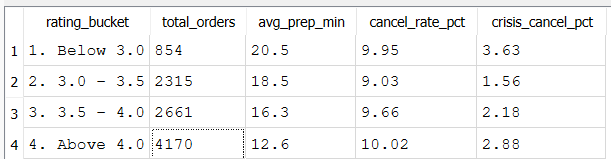

In [ ]:
Delivery partner load: orders per partner by city

SELECT
    d.city,
    o.city_tier,
    COUNT(DISTINCT d.delivery_partner_id)               AS active_partners,
    COUNT(*)                                             AS total_deliveries,
    ROUND(COUNT(*) * 1.0 /
          COUNT(DISTINCT d.delivery_partner_id), 1)     AS deliveries_per_partner,
    ROUND(AVG(d.delivery_time_min), 1)                  AS avg_delivery_min
FROM delivery d
JOIN orders o ON d.order_id = o.order_id
GROUP BY d.city, o.city_tier
ORDER BY deliveries_per_partner DESC;

Mumbai	Tier-1	50	1644	32.9	27.7
Coimbatore	Tier-2	50	1256	25.1	30.3
Indore	Tier-2	50	1256	25.1	30.4
Delhi	Tier-1	50	1212	24.2	28.1
Bhopal	Tier-2	50	1126	22.5	30.5
Bangalore	Tier-1	50	942	18.8	27.9
Vadodara	Tier-2	50	799	16.0	30.6
Surat	Tier-2	50	796	15.9	29.9


In [ ]:
SELECT
    o.city,
    o.city_tier,
    o.is_crisis_period,
    COUNT(*)                                                    AS orders,
    ROUND(AVG(r.rating), 2)                                    AS avg_restaurant_rating,
    ROUND(AVG(r.avg_prep_time), 1)                             AS avg_prep_min,
    ROUND(AVG(d.delivery_time_min), 1)                         AS avg_delivery_min,
    ROUND(AVG(CASE WHEN o.status='cancelled'
               THEN 1.0 ELSE 0 END) * 100, 1)                 AS cancel_rate_pct,
    ROUND(AVG(d.delay_flag) * 100, 1)                          AS delay_rate_pct
FROM orders o
JOIN restaurants r  ON o.restaurant_id = r.restaurant_id
LEFT JOIN delivery d ON o.order_id = d.order_id
GROUP BY o.city, o.city_tier, o.is_crisis_period
ORDER BY o.city_tier DESC, o.city, o.is_crisis_period;

Bhopal	Tier-2	0	1033	3.64	16.2	28.1	7.2	15.5
Bhopal	Tier-2	1	230	3.63	16.1	44.2	27.4	85.0
Coimbatore	Tier-2	0	1156	4.01	13.7	28.2	6.3	17.5
Coimbatore	Tier-2	1	225	3.99	13.8	44.0	23.1	79.2
Indore	Tier-2	0	1192	4.15	14.1	28.2	9.4	16.8
Indore	Tier-2	1	233	4.14	14.1	43.9	24.5	82.4
Surat	Tier-2	0	774	3.88	15.8	28.0	9.6	16.3
Surat	Tier-2	1	122	3.94	15.5	43.6	21.3	78.1
Vadodara	Tier-2	0	748	3.7	16.1	28.0	9.5	16.1
Vadodara	Tier-2	1	169	3.68	16.2	44.9	27.8	86.1
Bangalore	Tier-1	0	1031	3.58	16.9	27.9	8.6	15.6
Delhi	Tier-1	0	1304	3.71	16.9	28.1	7.1	16.5
Mumbai	Tier-1	0	1783	3.72	16.0	27.7	7.8	14.3
